# Retrieval Augmented Generation
RAG is a technique thta helps you work with large documents that are too big to fit into a single prompt. Instead of cramming everything into one prompt, RAG breaks documents into chunks and only include the most relevant pieces when answering questions.

Imagine you have an 800-page financial document and want to ask Claude specific questions about it, like "what risk factors does this company have?" You need to get the relevant information from the document to Claude and there are limits to how much text you can include in a prompt

### Option 1: Include everything in one prompt
Extract all text from document and include it in the prompt. It can look somethin like this
```
Answer the user's question about the financial document.
<user_question>
{user_question}
</user_question>

<financial_document>
{financial_document}
</financial_document>
```

### Option 2: Break documents into chunks
Break the document into smaller chunks during a preprocessing step. When a user asks a question, you find the chunks most relevant to their question and only include those in the prompt.

For example, if someone asks "What risks does this company face?" Youd search through the chunks and find the "Risk Factors" section, and include the chunks in your prompt

## Benefits of RAG
* Claude can focus on only the most relevant content
* Scales up to very large documents
* Works with multiple documents
* Smaller prompts cost less and run faster

## Challenges with RAG
* Requires preprocessing step to chunk documents
* Need a search mechanism to find "relevant" chunks
* Included chunks might not contain all the context Claude needs
* Many ways to chunk text, which way is best?

## Chunking Strategies
Each strategy heavily depends on the nature and structure of the document. There could be times where the document is not structured markdown with sections, so it's not possible to chunk by structure. 

##### Size Based
Divide the text into strings of equal length
* Include overlap on each side of the chunk to include some context
* Easy to implement, but might break up related content into separate chunks

##### Structure Based
Divide the text based upon the structure (headers, paragraphs, sections)
* Avoids breaking up related content into multiple chunks
* Requires us to understand the structure of the document beforehand

##### Semantic Based
Divide text into groups of related sentences or sections
* Require understanding of meaning of individual sentences
* Computationally expensive, but more relevant chunks

In [6]:
# Chunk by number of characters
def chunk_by_char(text, chunk_size=150, chunk_overlap=20):
    chunks = []
    start_idx = 0

    while start_idx < len(text):
        end_idx = min(start_idx + chunk_size, len(text))

        chunk_text = text[start_idx:end_idx]
        chunks.append(chunk_text)

        start_idx = (
            end_idx - chunk_overlap if end_idx < len(text) else len(text)
        )

    return chunks

In [7]:
# Chunk by sentences
import re

def chunk_by_sentence(text, max_sentences_per_chunk=5, overlap_sentences=1):
    sentences = re.split(r"(?<=[.!?])\s+", text)

    chunks = []
    start_idx = 0

    while start_idx < len(sentences):
        end_idx = min(start_idx + max_sentences_per_chunk, len(sentences))

        current_chunk = sentences[start_idx:end_idx]
        chunks.append(" ".join(current_chunk))

        start_idx += max_sentences_per_chunk - overlap_sentences

        if start_idx < 0:
            start_idx = 0
    return chunks

In [8]:
# Chunk by section
def chunk_by_section(document_text):
    pattern = r"\n## "
    return re.split(pattern, document_text)

In [9]:
with open("./report.md", "r") as f:
    text = f.read()

chunks = chunk_by_char(text, 500, 150)

[print(chunk + "\n----\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

## Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical ar
----

ddressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **Financial Analysis** revealed mixed quarterly perfor

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [10]:
with open("./report.md", "r") as f:
    text = f.read()

chunks = chunk_by_sentence(text)

[print(chunk + "\n----\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

## Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`).
----

Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **Financial Analysis** rev

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [11]:
with open("./report.md", "r") as f:
    text = f.read()

chunks = chunk_by_section(text)

[print(chunk + "\n----\n") for chunk in chunks]

# **Annual Interdisciplinary Research Review: Cross-Domain Insights**

----

Executive Summary

This report synthesizes the key findings and ongoing research efforts across the organization's diverse operational and R&D departments for the past fiscal year. Our strength lies in the cross-pollination of ideas and methodologies, driving innovation and addressing complex challenges that transcend traditional disciplinary boundaries. This year's review highlights significant progress in ten critical areas. Advances in **Medical Research** focused on the rare XDR-471 syndrome, yielding new diagnostic insights. Concurrently, **Software Engineering** tackled persistent stability issues, implementing key fixes identified through error code analysis (e.g., `ERR_MEM_ALLOC_FAIL_0x8007000E`). **Financial Analysis** revealed mixed quarterly performance, prompting strategic reviews, particularly concerning resource allocation impacting R&D pipelines.

Crucial developments were also seen in **Scienti

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## Text Embeddings
A text embedding is a numerical representation of the meaning contained in some text. Think of it as converting words and sentences into a format the computers can work with mathematically

Steps:
* Feed text into an embedding model 
* The model outputs a long list of numbers (the embeddings)
* Each number ranges from -1 to +1
* The numbers represent different qualities or features of the input text

In [12]:
from dotenv import load_dotenv
import voyageai

# Get an API key from https://www.voyageai.com
# Add VOYAGE_API_KEY="<your_api_key>" to your .env file
load_dotenv()

client = voyageai.Client()

In [13]:
def generate_embeddings(chunks, model="voyage-3-large", input_type="query"):
    is_list = isinstance(chunks, list)
    chunks_input = chunks if is_list else [chunks]

    result = client.embed(chunks_input, model=model, input_type=input_type)
    return result.embeddings if is_list else result.embeddings[0]

In [14]:
with open("./report.md", "r") as f:
    text = f.read()

chunks = chunk_by_section(text)

embeddings = generate_embeddings(chunks[0])
embeddings

[-0.05453480780124664,
 0.01431055087596178,
 -0.016921261325478554,
 0.0005922440905123949,
 0.02136913500726223,
 0.037903621792793274,
 -0.047186143696308136,
 0.0024173229467123747,
 0.0025865354109555483,
 -0.01798488199710846,
 0.014020473696291447,
 0.048926617950201035,
 -0.00918582733720541,
 -0.0037710238248109818,
 -0.013730393722653389,
 0.007010236848145723,
 0.03326236084103584,
 0.08857070654630661,
 -0.04737953096628189,
 -0.010201102122664452,
 0.06033638119697571,
 -0.057628974318504333,
 0.06497763842344284,
 -0.03461606428027153,
 -0.018468346446752548,
 0.007638740353286266,
 0.007203621789813042,
 0.04486551135778427,
 -0.03248881921172142,
 -0.014407243579626083,
 -0.000906496134120971,
 0.022142676636576653,
 0.01885511912405491,
 0.05685543641448021,
 0.012473385781049728,
 0.04099779576063156,
 -0.06188346818089485,
 -0.020402204245328903,
 -0.02726740390062332,
 -0.054921574890613556,
 0.010587873868644238,
 0.005245590582489967,
 0.032682206481695175,
 -0.07

## The full RAG workflow
### Step 1: Chunk your source Text
Turn the source document into manageable chunks. For this example we can chunk on the two Medical Research and Software Engineering sections


In [16]:
chunks = chunk_by_section(text)
chunks[2]

'Table of Contents\n\n1.  Executive Summary\n2.  Table of Contents\n3.  Methodology\n4.  Section 1: Medical Research - Understanding XDR-471 Syndrome\n5.  Section 2: Software Engineering - Project Phoenix Stability Enhancements\n6.  Section 3: Financial Analysis - Q3 Performance and Outlook\n7.  Section 4: Scientific Experimentation - Characterization of Material Composite XT-5\n8.  Section 5: Legal Developments - Navigating IP Precedents and Regulatory Shifts\n9.  Section 6: Product Engineering - Finalizing Model Zircon-5 Specifications\n10. Section 7: Historical Research - Re-evaluating the Galveston Accords (1921)\n11. Section 8: Project Management - Progress on Project Cerberus Phase 2B\n12. Section 9: Pharmaceutical Development - Compound CTX-204b Phase IIa Update\n13. Section 10: Cybersecurity Analysis - Incident Response Report\n14. Future Directions\n'

### Step 2: Generate Embeddings
Convert each text chunk into numerical embeddings using an embedding model.

The API will also perform a normalization step that scales each vector to be between 0-1

In [17]:
embeddings = generate_embeddings(chunks)

### Step 3: Store in a Vector Database
Store the generated embeddings into a vector database, which is optimized for storing, comparing, and searching through long lists of numbers like the embeddings

In [ ]:
# VectorIndex implementation
import math
from typing import Optional, Any, List, Dict, Tuple


class VectorIndex:
    def __init__(
        self,
        distance_metric: str = "cosine",
        embedding_fn=None,
    ):
        self.vectors: List[List[float]] = []
        self.documents: List[Dict[str, Any]] = []
        self._vector_dim: Optional[int] = None
        if distance_metric not in ["cosine", "euclidean"]:
            raise ValueError("distance_metric must be 'cosine' or 'euclidean'")
        self._distance_metric = distance_metric
        self._embedding_fn = embedding_fn

    def add_document(self, document: Dict[str, Any]):
        if not self._embedding_fn:
            raise ValueError(
                "Embedding function not provided during initialization."
            )
        if not isinstance(document, dict):
            raise TypeError("Document must be a dictionary.")
        if "content" not in document:
            raise ValueError(
                "Document dictionary must contain a 'content' key."
            )

        content = document["content"]
        if not isinstance(content, str):
            raise TypeError("Document 'content' must be a string.")

        vector = self._embedding_fn(content)
        self.add_vector(vector=vector, document=document)

    def add_documents(self, documents: List[Dict[str, Any]]):
        if not self._embedding_fn:
            raise ValueError(
                "Embedding function not provided during initialization."
            )

        if not isinstance(documents, list):
            raise TypeError("Documents must be a list of dictionaries.")

        if not documents:
            return

        contents = []
        for i, doc in enumerate(documents):
            if not isinstance(doc, dict):
                raise TypeError(f"Document at index {i} must be a dictionary.")
            if "content" not in doc:
                raise ValueError(
                    f"Document at index {i} must contain a 'content' key."
                )
            if not isinstance(doc["content"], str):
                raise TypeError(
                    f"Document 'content' at index {i} must be a string."
                )
            contents.append(doc["content"])

        vectors = self._embedding_fn(contents)

        for vector, document in zip(vectors, documents):
            self.add_vector(vector=vector, document=document)

    def search(
        self, query: Any, k: int = 1
    ) -> List[Tuple[Dict[str, Any], float]]:
        if not self.vectors:
            return []

        if isinstance(query, str):
            if not self._embedding_fn:
                raise ValueError(
                    "Embedding function not provided for string query."
                )
            query_vector = self._embedding_fn(query)
        elif isinstance(query, list) and all(
            isinstance(x, (int, float)) for x in query
        ):
            query_vector = query
        else:
            raise TypeError(
                "Query must be either a string or a list of numbers."
            )

        if self._vector_dim is None:
            return []

        if len(query_vector) != self._vector_dim:
            raise ValueError(
                f"Query vector dimension mismatch. Expected {self._vector_dim}, got {len(query_vector)}"
            )

        if k <= 0:
            raise ValueError("k must be a positive integer.")

        if self._distance_metric == "cosine":
            dist_func = self._cosine_distance
        else:
            dist_func = self._euclidean_distance

        distances = []
        for i, stored_vector in enumerate(self.vectors):
            distance = dist_func(query_vector, stored_vector)
            distances.append((distance, self.documents[i]))

        distances.sort(key=lambda item: item[0])

        return [(doc, dist) for dist, doc in distances[:k]]

    def add_vector(self, vector, document: Dict[str, Any]):
        if not isinstance(vector, list) or not all(
            isinstance(x, (int, float)) for x in vector
        ):
            raise TypeError("Vector must be a list of numbers.")
        if not isinstance(document, dict):
            raise TypeError("Document must be a dictionary.")
        if "content" not in document:
            raise ValueError(
                "Document dictionary must contain a 'content' key."
            )

        if not self.vectors:
            self._vector_dim = len(vector)
        elif len(vector) != self._vector_dim:
            raise ValueError(
                f"Inconsistent vector dimension. Expected {self._vector_dim}, got {len(vector)}"
            )

        self.vectors.append(list(vector))
        self.documents.append(document)

    def _euclidean_distance(
        self, vec1: List[float], vec2: List[float]
    ) -> float:
        if len(vec1) != len(vec2):
            raise ValueError("Vectors must have the same dimension")
        return math.sqrt(sum((p - q) ** 2 for p, q in zip(vec1, vec2)))

    def _dot_product(self, vec1: List[float], vec2: List[float]) -> float:
        if len(vec1) != len(vec2):
            raise ValueError("Vectors must have the same dimension")
        return sum(p * q for p, q in zip(vec1, vec2))

    def _magnitude(self, vec: List[float]) -> float:
        return math.sqrt(sum(x * x for x in vec))

    def _cosine_distance(self, vec1: List[float], vec2: List[float]) -> float:
        if len(vec1) != len(vec2):
            raise ValueError("Vectors must have the same dimension")

        mag1 = self._magnitude(vec1)
        mag2 = self._magnitude(vec2)

        if mag1 == 0 and mag2 == 0:
            return 0.0
        elif mag1 == 0 or mag2 == 0:
            return 1.0

        dot_prod = self._dot_product(vec1, vec2)
        cosine_similarity = dot_prod / (mag1 * mag2)
        cosine_similarity = max(-1.0, min(1.0, cosine_similarity))

        return 1.0 - cosine_similarity

    def __len__(self) -> int:
        return len(self.vectors)

    def __repr__(self) -> str:
        has_embed_fn = "Yes" if self._embedding_fn else "No"
        return f"VectorIndex(count={len(self)}, dim={self._vector_dim}, metric='{self._distance_metric}', has_embedding_fn='{has_embed_fn}')"

In [20]:
store = VectorIndex()

for embedding, chunk in zip(embeddings, chunks):
    store.add_vector(embedding, {"content": chunk})


### Step 4: Process User Query
Run the use rquery through the same embedding model

In [21]:
user_embedding = generate_embeddings("What did the software engineering department do last year?")

### Step 5: Find Similar Embeddings
Send the user query to the vector database and find the most similar stored embeddings.

This uses cosine similarity to determine which embeddings are the most similar.
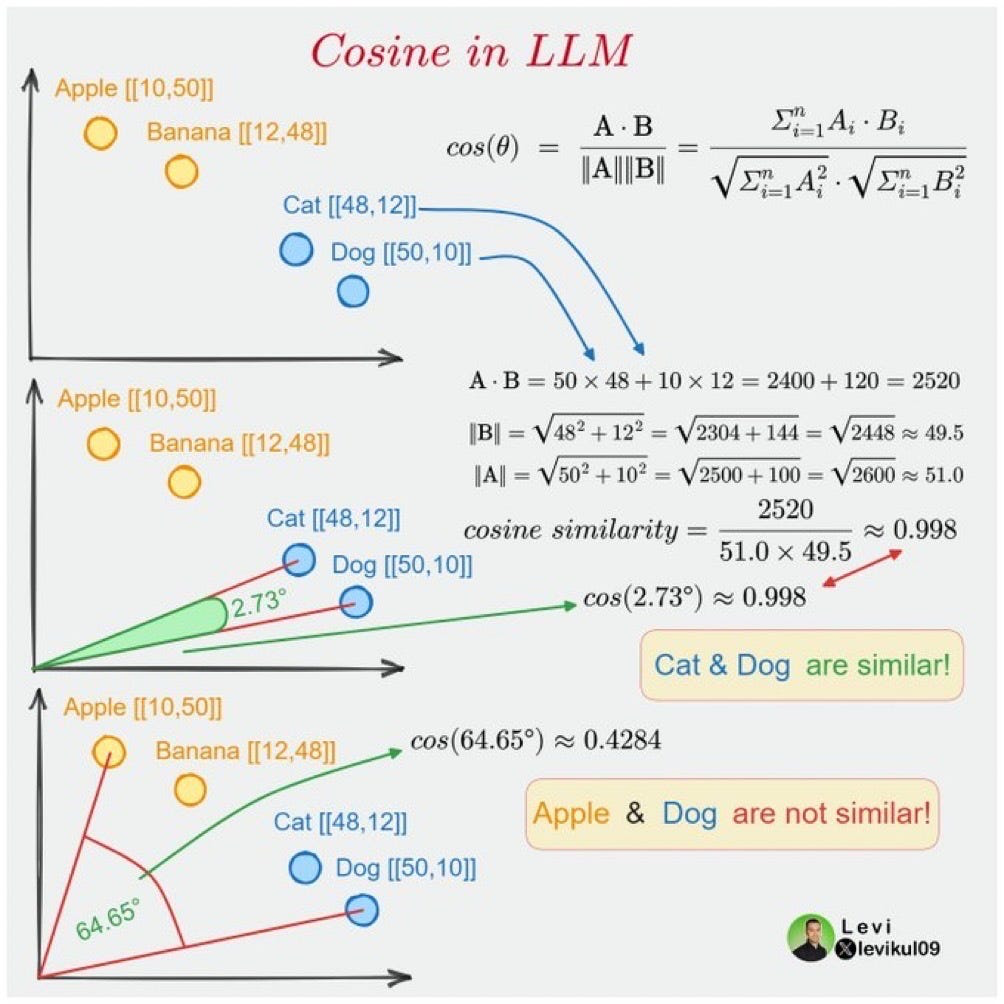

Key points:
* Results range from -1 to 1
* Values close to 1 mean high similarity
* Values close to -1 mean very different
* 0 means perpendicular (no relationship)

You can also interpert the result using cosine distance `(1 - cosine similarity)` which makes it easier to interpert:
* Values closer to 0 mean high similarity
* Larger values mean less similarity

In [26]:
# Find the two most relevant chunks
results = store.search(user_embedding, 2)

for doc, distance in results:
    print(distance, "\n", doc["content"][:200], "\n")
print("----------\n")


# Semantic search alone could still return irrelevant chunks it thinks are related to what the user asked for

inc_embedding = generate_embeddings("What happened with INC-2023-Q4-011")

results = store.search(inc_embedding, 2)
for doc, distance in results:
    print(distance, "\n", doc["content"][:200], "\n")


0.47144835866209656 
 Section 2: Software Engineering - Project Phoenix Stability Enhancements

The Software Engineering division dedicated considerable effort to improving the stability and performance of the core systems 

0.4772227671227336 
 Future Directions

This year's cross-domain insights underscore the interconnectedness of our diverse research and operational activities. The stability enhancements achieved in Software Engineering ( 

----------

0.49546213246837834 
 Section 10: Cybersecurity Analysis - Incident Response Report: INC-2023-Q4-011

The Cybersecurity Operations Center successfully contained and remediated a targeted intrusion attempt tracked as `INC-2 

0.5283171042749383 
 Section 2: Software Engineering - Project Phoenix Stability Enhancements

The Software Engineering division dedicated considerable effort to improving the stability and performance of the core systems 



#### Hybrid Search
The solution is to run semantic and lexical searches in parallel then merge the results.
For the lexical search we're going to use the industry standard BM25 algorithm

1. Tokenize the query: Break the question into individual terms. For example "a world" becomes ["a", "world"]
2. Count term frequency: See how often each term appears across all documents. Common words like "a" might appear 7 times while terms like "world" might only appear once.
3. Weight terms by importance: Terms that appear less get higher importance. The word "a" gets low importance because it's common, while "world" gets high importance because it's rare
4. Find best matches: Return documents containing more instances of higher weighted terms 

In [31]:
import math
from collections import Counter
from typing import Callable, Optional, Any, List, Dict, Tuple


class BM25Index:
    def __init__(
        self,
        k1: float = 1.5,
        b: float = 0.75,
        tokenizer: Optional[Callable[[str], List[str]]] = None,
    ):
        self.documents: List[Dict[str, Any]] = []
        self._corpus_tokens: List[List[str]] = []
        self._doc_len: List[int] = []
        self._doc_freqs: Dict[str, int] = {}
        self._avg_doc_len: float = 0.0
        self._idf: Dict[str, float] = {}
        self._index_built: bool = False

        self.k1 = k1
        self.b = b
        self._tokenizer = tokenizer if tokenizer else self._default_tokenizer

    def _default_tokenizer(self, text: str) -> List[str]:
        text = text.lower()
        tokens = re.split(r"\W+", text)
        return [token for token in tokens if token]

    def _update_stats_add(self, doc_tokens: List[str]):
        self._doc_len.append(len(doc_tokens))

        seen_in_doc = set()
        for token in doc_tokens:
            if token not in seen_in_doc:
                self._doc_freqs[token] = self._doc_freqs.get(token, 0) + 1
                seen_in_doc.add(token)

        self._index_built = False

    def _calculate_idf(self):
        N = len(self.documents)
        self._idf = {}
        for term, freq in self._doc_freqs.items():
            idf_score = math.log(((N - freq + 0.5) / (freq + 0.5)) + 1)
            self._idf[term] = idf_score

    def _build_index(self):
        if not self.documents:
            self._avg_doc_len = 0.0
            self._idf = {}
            self._index_built = True
            return

        self._avg_doc_len = sum(self._doc_len) / len(self.documents)
        self._calculate_idf()
        self._index_built = True

    def add_document(self, document: Dict[str, Any]):
        if not isinstance(document, dict):
            raise TypeError("Document must be a dictionary.")
        if "content" not in document:
            raise ValueError(
                "Document dictionary must contain a 'content' key."
            )

        content = document.get("content", "")
        if not isinstance(content, str):
            raise TypeError("Document 'content' must be a string.")

        doc_tokens = self._tokenizer(content)

        self.documents.append(document)
        self._corpus_tokens.append(doc_tokens)
        self._update_stats_add(doc_tokens)

    def add_documents(self, documents: List[Dict[str, Any]]):
        if not isinstance(documents, list):
            raise TypeError("Documents must be a list of dictionaries.")

        if not documents:
            return

        for i, doc in enumerate(documents):
            if not isinstance(doc, dict):
                raise TypeError(f"Document at index {i} must be a dictionary.")
            if "content" not in doc:
                raise ValueError(
                    f"Document at index {i} must contain a 'content' key."
                )
            if not isinstance(doc["content"], str):
                raise TypeError(
                    f"Document 'content' at index {i} must be a string."
                )

            content = doc["content"]
            doc_tokens = self._tokenizer(content)

            self.documents.append(doc)
            self._corpus_tokens.append(doc_tokens)
            self._update_stats_add(doc_tokens)

    def _compute_bm25_score(
        self, query_tokens: List[str], doc_index: int
    ) -> float:
        score = 0.0
        doc_term_counts = Counter(self._corpus_tokens[doc_index])
        doc_length = self._doc_len[doc_index]

        for token in query_tokens:
            if token not in self._idf:
                continue

            idf = self._idf[token]
            term_freq = doc_term_counts.get(token, 0)

            numerator = idf * term_freq * (self.k1 + 1)
            denominator = term_freq + self.k1 * (
                1 - self.b + self.b * (doc_length / self._avg_doc_len)
            )
            score += numerator / (denominator + 1e-9)

        return score

    def search(
        self,
        query_text: str,
        k: int = 1,
        score_normalization_factor: float = 0.1,
    ) -> List[Tuple[Dict[str, Any], float]]:
        if not self.documents:
            return []

        if not isinstance(query_text, str):
            raise TypeError("Query text must be a string.")

        if k <= 0:
            raise ValueError("k must be a positive integer.")

        if not self._index_built:
            self._build_index()

        if self._avg_doc_len == 0:
            return []

        query_tokens = self._tokenizer(query_text)
        if not query_tokens:
            return []

        raw_scores = []
        for i in range(len(self.documents)):
            raw_score = self._compute_bm25_score(query_tokens, i)
            if raw_score > 1e-9:
                raw_scores.append((raw_score, self.documents[i]))

        raw_scores.sort(key=lambda item: item[0], reverse=True)

        normalized_results = []
        for raw_score, doc in raw_scores[:k]:
            normalized_score = math.exp(-score_normalization_factor * raw_score)
            normalized_results.append((doc, normalized_score))

        normalized_results.sort(key=lambda item: item[1])

        return normalized_results

    def __len__(self) -> int:
        return len(self.documents)

    def __repr__(self) -> str:
        return f"BM25VectorStore(count={len(self)}, k1={self.k1}, b={self.b}, index_built={self._index_built})"

In [ ]:
bm_store = BM25Index()

for chunk in chunks:
    bm_store.add_document({"content": chunk})

results = bm_store.search("What happened with What happened with INC-2023-Q4-011?", 3)

# Notice how software engineering section is now prioritzed
for doc, distance in results:
    print(distance, "\n", doc["content"][:200], "\n------\n")

0.26047315038268276 
 Section 2: Software Engineering - Project Phoenix Stability Enhancements

The Software Engineering division dedicated considerable effort to improving the stability and performance of the core systems 
------

0.3126468805076907 
 Section 10: Cybersecurity Analysis - Incident Response Report: INC-2023-Q4-011

The Cybersecurity Operations Center successfully contained and remediated a targeted intrusion attempt tracked as `INC-2 
------

0.88194263799116 
 Methodology

The insights compiled within this Annual Interdisciplinary Research Review represent a synthesis of findings drawn from standard departmental reporting cycles, specialized project updates 
------



### Step 6: Create Final Prompt
Take the user and most relevant chunk we found, combine them into a prompt and send it to Claude for a response

In [35]:
# Retriever implementation
from typing import Any, List, Dict, Tuple, Protocol


class SearchIndex(Protocol):
    def add_document(self, document: Dict[str, Any]) -> None: ...

    # Added the 'add_documents' method to avoid rate limiting errors from VoyageAI
    def add_documents(self, documents: List[Dict[str, Any]]) -> None: ...

    def search(
        self, query: Any, k: int = 1
    ) -> List[Tuple[Dict[str, Any], float]]: ...


class Retriever:
    def __init__(self, *indexes: SearchIndex):
        if len(indexes) == 0:
            raise ValueError("At least one index must be provided")
        self._indexes = list(indexes)

    def add_document(self, document: Dict[str, Any]):
        for index in self._indexes:
            index.add_document(document)

    # Added the 'add_documents' method to avoid rate limiting errors from VoyageAI
    def add_documents(self, documents: List[Dict[str, Any]]):
        for index in self._indexes:
            index.add_documents(documents)

    def search(
        self, query_text: str, k: int = 1, k_rrf: int = 60
    ) -> List[Tuple[Dict[str, Any], float]]:
        if not isinstance(query_text, str):
            raise TypeError("Query text must be a string.")
        if k <= 0:
            raise ValueError("k must be a positive integer.")
        if k_rrf < 0:
            raise ValueError("k_rrf must be non-negative.")

        all_results = [
            index.search(query_text, k=k * 5) for index in self._indexes
        ]

        doc_ranks = {}
        for idx, results in enumerate(all_results):
            for rank, (doc, _) in enumerate(results):
                doc_id = id(doc)
                if doc_id not in doc_ranks:
                    doc_ranks[doc_id] = {
                        "doc_obj": doc,
                        "ranks": [float("inf")] * len(self._indexes),
                    }
                doc_ranks[doc_id]["ranks"][idx] = rank + 1

        def calc_rrf_score(ranks: List[float]) -> float:
            return sum(1.0 / (k_rrf + r) for r in ranks if r != float("inf"))

        scored_docs: List[Tuple[Dict[str, Any], float]] = [
            (ranks["doc_obj"], calc_rrf_score(ranks["ranks"]))
            for ranks in doc_ranks.values()
        ]

        filtered_docs = [
            (doc, score) for doc, score in scored_docs if score > 0
        ]
        filtered_docs.sort(key=lambda x: x[1], reverse=True)

        return filtered_docs[:k]

In [37]:
vector_index = VectorIndex(embedding_fn=generate_embeddings)
bm25_index = BM25Index()
retriever = Retriever(vector_index, bm25_index)

for chunk in chunks:
    retriever.add_document({"content": chunk})

RateLimitError: You have not yet added your payment method in the billing page and will have reduced rate limits of 3 RPM and 10K TPM. To unlock our standard rate limits, please add a payment method in the billing page for the appropriate organization in the user dashboard (https://dashboard.voyageai.com/). Even with payment methods entered, the free tokens (200M tokens for Voyage series 3) will still apply. After adding a payment method, you should see your rate limits increase after several minutes. See our pricing docs (https://docs.voyageai.com/docs/pricing) for the free tokens for your model.